In [15]:
import numpy as np
import json
from pathlib import Path
from matplotlib import pyplot as plt

from usecases.utils.test_nb_functions import plot_multiple_responses, rmse_complex, transfer_function

## Чтение данных из csv-файлов

Директория с файлами и имена.

In [16]:
sample_dir = Path("usecases/test_samples/experiments_13_May_2026")

sample_file_name_list = [
    "Zout_300_AP",
    "Zouti_300_AP",
    "Wui_300_DP",
    "Wui_delay_300_DP",
    "G_I_PID_300_DP",
    "G_U_PI_300_DP",
    "G_I_PI_300_DP"
    ]
ext = '.csv'

data_list = []
for sample_file_name in sample_file_name_list:
    data_list.append(np.loadtxt(sample_dir / (sample_file_name + ext), delimiter=',', skiprows=1).T)

Интерполяция данных.

In [17]:
data_list_interp = []
for data in data_list:
    freq = data[0,:]
    mag_ph = np.array([data[1,:], data[2,:]])

    freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
    mag_ph_interp = np.array([np.interp(freq_log, freq, y) for y in mag_ph])
    data_interp = np.vstack((freq_log, mag_ph_interp))
    data_list_interp.append(data_interp)
data_list = data_list_interp.copy()

Координаты полюсов/нулей.

In [18]:
Uout = 48
Pout_nom = 120
Uin = 24
R = 19.2+1
L = 136e-6
C = 4 * 100e-6 *1.1
ESR = 87e-3 / 4 * 0.6

Le = (Uout / Uin)**2 * L *1.1

w_c = 1 / (R*C)
w_ESR = 1 / (ESR*C)
w_RHP = R / Le

zeros_poles_list = [
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [25e3],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 230.0,
    "delay": 0.0
    },
    {
    "left_poles": [39],
    "right_poles": [],
    "left_zeros": [25e3],
    "right_zeros": [],
    "zero_poles": 0,
    "gain": 0.9,
    "delay": 0.0
    },
    {
    "left_poles": [39],
    "right_poles": [],
    "left_zeros": [25e3],
    "right_zeros": [5e3],
    "zero_poles": 0,
    "gain": 4.0,
    "delay": 5e-6
    },
    {
    "left_poles": [39],
    "right_poles": [],
    "left_zeros": [25e3],
    "right_zeros": [5e3],
    "zero_poles": 0,
    "gain": 4.0,
    "delay": 15e-6
    },
    {
    "left_poles": [42e3],
    "right_poles": [],
    "left_zeros": [380, 17e3],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 3550.0,
    "delay": 0.0
    },
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [270],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 3500.0,
    "delay": 0.0
    },
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [1.5e3],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 8250.0,
    "delay": 0.0
    }    
]

In [19]:
estim_list = []
for mask, data in zip(zeros_poles_list, data_list):
        freq = data[0,:]
        gain_complex = transfer_function(
                freq=freq,
                zero_poles=mask["zero_poles"],
                poles=mask["left_poles"] + (-1 * np.array(mask["right_poles"])).tolist(),
                zeros=mask["left_zeros"] + (-1 * np.array(mask["right_zeros"])).tolist(),
                gain=mask["gain"],
                delay=mask["delay"]
                )
        magnitude = 20*np.log10(np.abs(gain_complex))
        phase = 180 / np.pi * np.unwrap(np.angle(gain_complex))
        
        estim_list.append(np.array([freq, magnitude, phase]))

## Визуализация

In [20]:
with open('usecases/plot_config.json', 'r', encoding='utf-8') as f:
    PLOT_CONFIG = json.load(f)

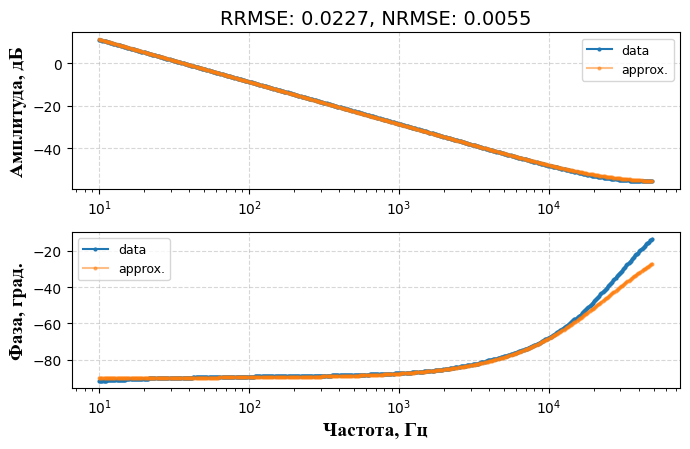

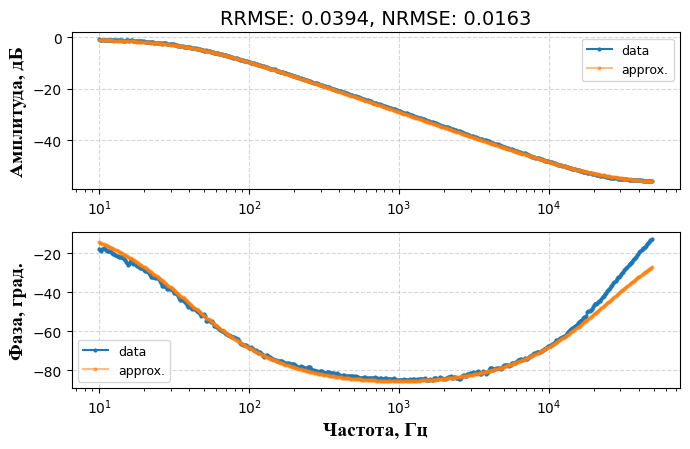

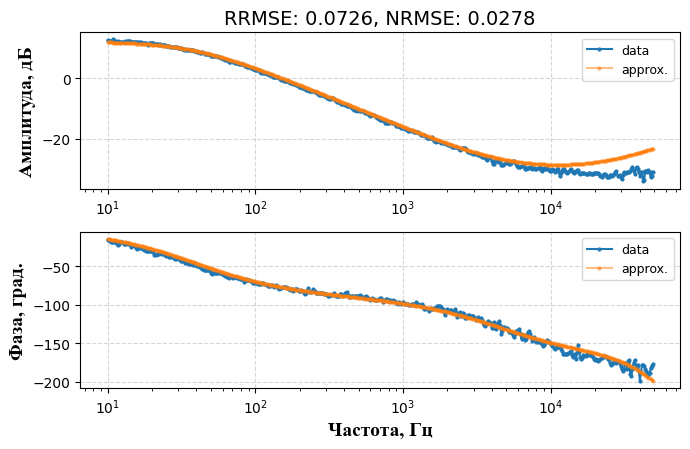

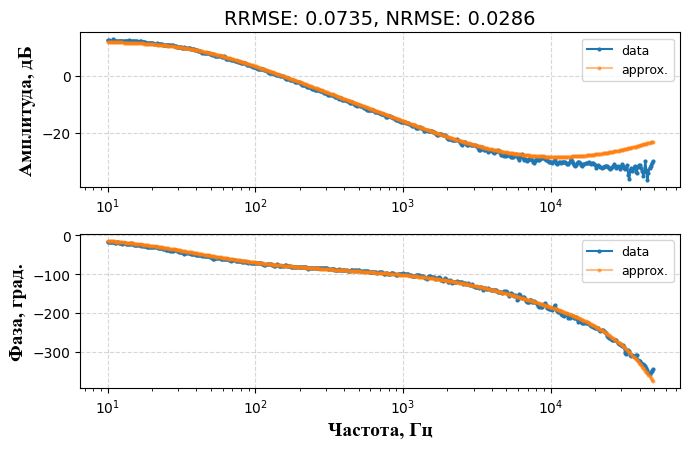

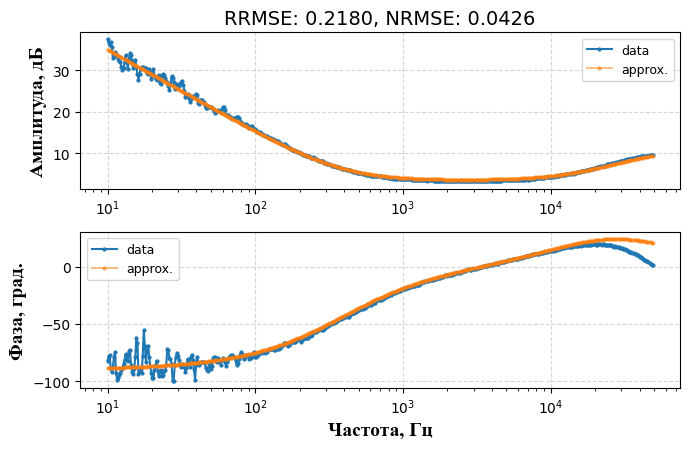

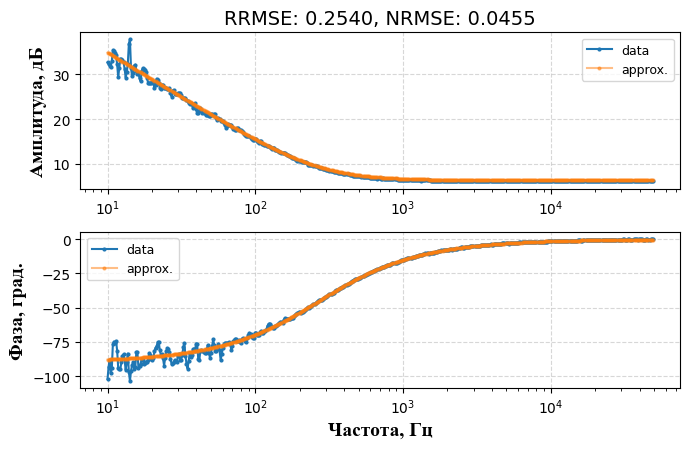

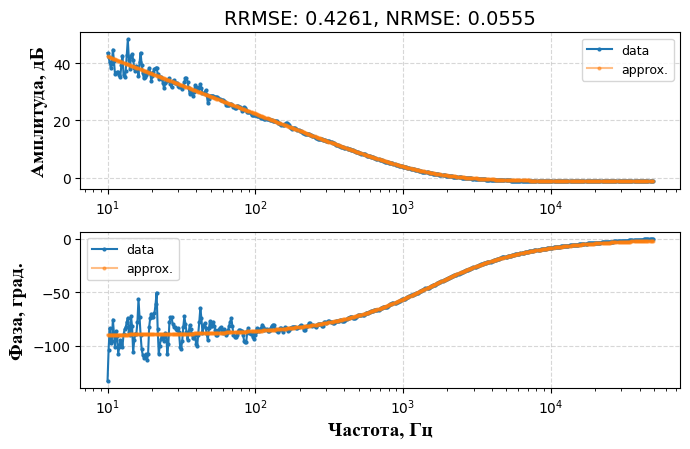

In [21]:
for data, estim, zeros_poles, sample_file_name in zip(
    data_list,
    estim_list,
    zeros_poles_list,
    sample_file_name_list
    ):

    _, RRMSE, NRMSE = rmse_complex(
        response_in=estim,
        response_ref=data
        #Nlim=[100, None]
        )

    plot_multiple_responses(
        plot_config=PLOT_CONFIG,
        data_list=[data, estim],
        legend=["data", "approx."],
        title=f'RRMSE: {RRMSE:.4f}, NRMSE: {NRMSE:.4f}',
        #save_path=f'usecases/test_samples/experiments_13_May_2026/pdf/{sample_file_name}.pdf'
        )